Variables
    - Quantitaive Variables
        --Latutude
        --Longitude
        

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
df = pd.read_csv("data/2018_Central_Park_Squirrel_Census_-_Squirrel_Data_20260303.csv")
df.head()

,X,Y,Unique Squirrel ID,Hectare,Shift,Date,Hectare Squirrel Number,Age,Primary Fur Color,Highlight Fur Color,...,Kuks,Quaas,Moans,Tail flags,Tail twitches,Approaches,Indifferent,Runs from,Other Interactions,Lat/Long
0,-73.956134,40.794082,37F-PM-1014-03,37F,PM,10142018,3,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.9561344937861 40.7940823884086)
1,-73.968857,40.783783,21B-AM-1019-04,21B,AM,10192018,4,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.9688574691102 40.7837825208444)
2,-73.974281,40.775534,11B-PM-1014-08,11B,PM,10142018,8,NaN,Gray,NaN,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.97428114848522 40.775533619083)
3,-73.959641,40.790313,32E-PM-1017-14,32E,PM,10172018,14,Adult,Gray,NaN,...,False,False,False,False,False,False,False,True,NaN,POINT (-73.9596413903948 40.7903128889029)
4,-73.970268,40.776213,13E-AM-1017-05,13E,AM,10172018,5,Adult,Gray,Cinnamon,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.9702676472613 40.7762126854894)


In [6]:
#Looking at summary variables
df.describe()

,X,Y,Date,Hectare Squirrel Number
count,3023.000000,3023.000000,3.023000e+03,3023.000000
mean,-73.967184,40.780853,1.011949e+07,4.123718
std,0.007726,0.010285,4.246671e+04,3.096492
min,-73.981159,40.764911,1.006202e+07,1.000000
25%,-73.973102,40.771676,1.008202e+07,2.000000
50%,-73.968594,40.778166,1.012202e+07,3.000000
75%,-73.960189,40.791219,1.014202e+07,6.000000
max,-73.949722,40.800119,1.020202e+07,23.000000


Now looking at our summary statistics longitude and latitude we can create an isolated summary statistics table for them.

In [8]:
quant_vars = df[['X', 'Y']]

summary_stats = quant_vars.describe()
summary_stats

,X,Y
count,3023.000000,3023.000000
mean,-73.967184,40.780853
std,0.007726,0.010285
min,-73.981159,40.764911
25%,-73.973102,40.771676
50%,-73.968594,40.778166
75%,-73.960189,40.791219
max,-73.949722,40.800119


To understand more about Longitude and Latitude we can look at how these variables are distributed.

In [32]:
plt.figure()
sns.histplot(df['X'], bins=30)
plt.title("Distribution of Longitude (X)")
plt.savefig("longitude_distribution.png", bbox_inches="tight")
plt.close()

plt.figure()
sns.histplot(df['Y'], bins=30)
plt.title("Distribution of Latitude (Y)")
plt.savefig("latitude_distribution.png", bbox_inches="tight")
plt.close()

Now we can then pick 2 categorical variables.

I'm going to use the variables primary fur color and shift.


Since these two variables are categorical , we can look at the frequencies at which they appear.


In [13]:
df['Primary Fur Color'].value_counts()


Primary Fur Color
Gray        2473
Cinnamon     392
Black        103
Name: count, dtype: int64

In [12]:
df['Shift'].value_counts()

Shift
PM    1676
AM    1347
Name: count, dtype: int64

We can also visualize these frequencies.

In [31]:
plt.figure()
df['Primary Fur Color'].value_counts().plot(kind='bar')
plt.title("Primary Fur Color Distribution")
plt.savefig("fur_distribution.png", bbox_inches="tight")
plt.close()

plt.figure()
df['Shift'].value_counts().plot(kind='bar')
plt.title("Shift Distribution (AM vs PM)")
plt.savefig("shift_distribution.png", bbox_inches="tight")
plt.close()


Now , onto our ordinal variables. I'm going to use the variables "Age" and "Location" . However I will be converting them to ordinal variables.

In [17]:
df['Age'] = pd.Categorical(
    df['Age'],
    categories=['Juvenile', 'Adult'],
    ordered=True
)

df['Age'] 


0         NaN
1         NaN
2         NaN
3       Adult
4       Adult
        ...  
3018    Adult
3019    Adult
3020    Adult
3021      NaN
3022    Adult
Name: Age, Length: 3023, dtype: category
Categories (2, object): ['Juvenile' < 'Adult']

In [16]:

df['Location'] = pd.Categorical(
    df['Location'],
    categories=['Ground Plane', 'Above Ground'],
    ordered=True
)

df['Location']

0                NaN
1                NaN
2       Above Ground
3                NaN
4       Above Ground
            ...     
3018    Ground Plane
3019    Ground Plane
3020    Ground Plane
3021    Ground Plane
3022    Ground Plane
Name: Location, Length: 3023, dtype: category
Categories (2, object): ['Ground Plane' < 'Above Ground']

We can now construct similar frequency planes for our two ordinal variables.

In [19]:
df['Age'].value_counts()


Age
Adult       2568
Juvenile     330
Name: count, dtype: int64

In [20]:
df['Location'].value_counts()

Location
Ground Plane    2116
Above Ground     843
Name: count, dtype: int64

Similarly , we can visualize these counts using a bar chart.

In [30]:
plt.figure()
df['Age'].value_counts().plot(kind='bar')
plt.title("Age Distribution")
plt.savefig("age_distribution.png", bbox_inches="tight")
plt.close()


plt.figure()
df['Location'].value_counts().plot(kind='bar')
plt.title("Location Distribution")
plt.savefig("location_distribution.png", bbox_inches="tight")
plt.close()

In [29]:
age_location = pd.crosstab(df['Age'], df['Location'])
age_location.plot(kind='bar')
plt.title("Age vs Location")
plt.ylabel("Count")

plt.savefig("age_location.png", bbox_inches="tight")
plt.close()

In [28]:
color_age = pd.crosstab(df['Primary Fur Color'], df['Age'])

color_age.plot(kind='bar')
plt.title("Fur Color vs Age")
plt.savefig("Color_Age.png", bbox_inches="tight")
plt.close()

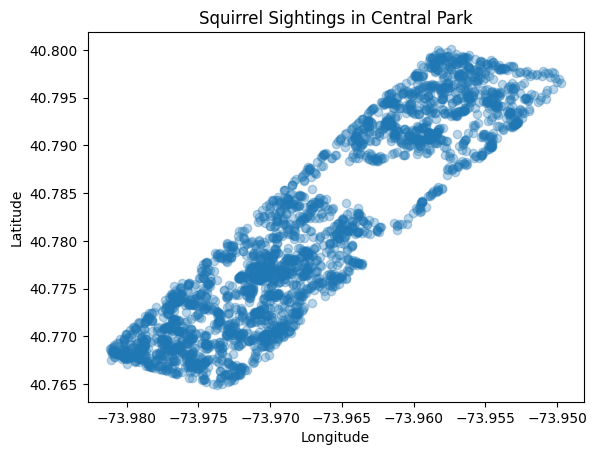

In [27]:
plt.figure()
plt.scatter(df['X'], df['Y'], alpha=0.3)
plt.title("Squirrel Sightings in Central Park")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


plt.savefig("Squirrel_sightings.png", bbox_inches="tight")
plt.close()

My three hypotheses are:
        1. Adult squirrels are more likely to be observed above ground than juveniles.
        2. Gray squirrels make up more than 60% of sightings.
        3. Squirrels sighted in the PM shift are more likely to be on the ground than in AM.